In [2]:
import sqlite3
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)

In [3]:
conn = sqlite3.connect('../01-data/processed/shopstream.db')

In [4]:
events = pd.read_sql("""
SELECT *
FROM events
""", conn)

orders = pd.read_sql("""
SELECT *
FROM orders
""", conn)

order_items = pd.read_sql("""
SELECT *
FROM order_items
""", conn)

users = pd.read_sql("""
SELECT *
FROM users
""", conn)

products = pd.read_sql("""
SELECT *
FROM products
""", conn)

In [5]:
print("Events:", events.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Users:", users.shape)
print("Products:", products.shape)

Events: (2431963, 13)
Orders: (125226, 9)
Order Items: (181759, 11)
Users: (100000, 15)
Products: (29120, 9)


In [6]:
events['event_type'].value_counts()

event_type
product       845607
cart          595994
department    595323
purchase      181759
cancel        125568
home           87712
Name: count, dtype: int64

In [7]:
funnel_users = pd.DataFrame({

    'Stage':[
        'Homepage Visitors',
        'Department Viewers',
        'Product Viewers',
        'Cart Adders',
        'Purchasers'
    ],

    'Users':[

        events.loc[
            events['event_type']=='home',
            'user_id'
        ].nunique(),

        events.loc[
            events['event_type']=='department',
            'user_id'
        ].nunique(),

        events.loc[
            events['event_type']=='product',
            'user_id'
        ].nunique(),

        events.loc[
            events['event_type']=='cart',
            'user_id'
        ].nunique(),

        events.loc[
            events['event_type']=='purchase',
            'user_id'
        ].nunique()
    ]
})

funnel_users

,Stage,Users
0,Homepage Visitors,63197
1,Department Viewers,80044
2,Product Viewers,80044
3,Cart Adders,80044
4,Purchasers,80044


In [8]:
funnel_users['Stage_Conversion_Rate_%'] = (

    funnel_users['Users']
    /
    funnel_users['Users'].shift(1)
    *100

)

funnel_users['Cumulative_Conversion_%'] = (

    funnel_users['Users']
    /
    funnel_users.iloc[0]['Users']
    *100

)

funnel_users

,Stage,Users,Stage_Conversion_Rate_%,Cumulative_Conversion_%
0,Homepage Visitors,63197,NaN,100.000000
1,Department Viewers,80044,126.657911,126.657911
2,Product Viewers,80044,100.000000,126.657911
3,Cart Adders,80044,100.000000,126.657911
4,Purchasers,80044,100.000000,126.657911


In [9]:
avg_order_value = (

    order_items['sale_price']
    .mean()

)

cart_users = events.loc[
    events['event_type']=='cart',
    'user_id'
].nunique()

purchase_users = events.loc[
    events['event_type']=='purchase',
    'user_id'
].nunique()

users_dropped_after_cart = (

    cart_users
    -
    purchase_users
)

revenue_at_risk = (

    users_dropped_after_cart
    *
    avg_order_value
)

print("Dropped Users:", users_dropped_after_cart)
print("Average Order Value:", round(avg_order_value,2))
print("Revenue At Risk:", round(revenue_at_risk,2))

Dropped Users: 0
Average Order Value: 59.57
Revenue At Risk: 0.0


In [10]:
events.columns

Index(['id', 'user_id', 'sequence_number', 'session_id', 'created_at',
       'ip_address', 'city', 'state', 'postal_code', 'browser',
       'traffic_source', 'uri', 'event_type'],
      dtype='object')

In [11]:
events[['user_id','event_type','created_at']].head(10)

,user_id,event_type,created_at
0,NaN,cancel,2021-06-17 17:30:00+00:00
1,NaN,cancel,2020-08-07 08:41:00+00:00
2,NaN,cancel,2021-02-15 18:48:00+00:00
3,NaN,cancel,2022-03-30 10:56:00+00:00
4,NaN,cancel,2019-09-05 01:18:00+00:00
5,NaN,cancel,2020-09-16 19:35:00+00:00
6,NaN,cancel,2021-08-25 12:38:00+00:00
7,NaN,cancel,2022-05-30 06:41:00+00:00
8,NaN,cancel,2023-07-08 05:36:00+00:00
9,NaN,cancel,2021-09-16 08:56:00+00:00


In [12]:
events['user_id'].isna().sum(), events['user_id'].notna().sum()

(1125671, 1306292)

In [13]:
events_valid = events[
    events['user_id'].notna()
].copy()

events_valid.shape

(1306292, 13)

In [14]:
events_valid['event_type'].value_counts()

event_type
cart          345607
department    345607
product       345607
purchase      181759
home           87712
Name: count, dtype: int64

In [15]:
events_valid.groupby('event_type')['user_id'].nunique()

event_type
cart          80044
department    80044
home          63197
product       80044
purchase      80044
Name: user_id, dtype: int64

In [16]:
orders['user_id'].nunique()

80044

In [17]:
funnel_summary = pd.DataFrame({

    'Stage':[
        'Homepage Visitors',
        'Product Viewers',
        'Cart Adders',
        'Purchasers'
    ],

    'Users':[
        63197,
        80044,
        80044,
        80044
    ]
})

funnel_summary

,Stage,Users
0,Homepage Visitors,63197
1,Product Viewers,80044
2,Cart Adders,80044
3,Purchasers,80044


### Dataset Limitation

The ShopStream event model does not contain a strict sequential funnel.

Users associated with product, cart, and purchase events overlap almost completely, causing traditional stage-to-stage drop-off analysis to be statistically insignificant.

Therefore, funnel analysis focuses on user reach, device performance, traffic source efficiency, conversion timing, and cart abandonment rather than strict event progression.

In [18]:
events_valid['browser'].value_counts().head(20)

browser
Chrome     656794
Firefox    261951
Safari     258463
Other       64614
IE          64470
Name: count, dtype: int64

In [19]:
browser_device_map = {
    'Chrome':'Desktop',
    'Firefox':'Desktop',
    'IE':'Desktop',
    'Safari':'Mobile',
    'Other':'Tablet'
}

In [20]:
events_valid['device_type'] = (
    events_valid['browser']
    .map(browser_device_map)
)

events_valid['device_type'].value_counts()

device_type
Desktop    983215
Mobile     258463
Tablet      64614
Name: count, dtype: int64

In [21]:
device_users = (

    events_valid

    .groupby('device_type')['user_id']

    .nunique()

    .reset_index(name='users')

)

device_users

,device_type,users
0,Desktop,69988
1,Mobile,28949
2,Tablet,8508


In [22]:
device_purchases = (

    events_valid[
        events_valid['event_type'] == 'purchase'
    ]

    .groupby('device_type')['user_id']

    .nunique()

    .reset_index(name='purchasers')

)

device_purchases

,device_type,purchasers
0,Desktop,69988
1,Mobile,28949
2,Tablet,8508


### Dataset Limitation: Device Conversion Analysis

The event dataset contains only users who eventually completed a purchase. As a result, device-level conversion rates equal 100% across Desktop, Mobile, and Tablet users.

Because there is no variation in conversion outcomes, statistical significance testing (Z-test) cannot be meaningfully performed. Device analysis is therefore limited to user distribution and traffic volume comparisons.

In [23]:
device_summary = pd.DataFrame({

    'Device_Type':['Desktop','Mobile','Tablet'],

    'Users':[69988,28949,8508],

    'Pct_Of_Users':[

        round(69988/107445*100,2),

        round(28949/107445*100,2),

        round(8508/107445*100,2)

    ]
})

device_summary

,Device_Type,Users,Pct_Of_Users
0,Desktop,69988,65.14
1,Mobile,28949,26.94
2,Tablet,8508,7.92


## Device Distribution

| Device | Users | % of Users |
|----------|---------:|---------:|
| Desktop | 69,988 | 65.14% |
| Mobile | 28,949 | 26.94% |
| Tablet | 8,508 | 7.92% |

### Key Findings
- Desktop users represent nearly two-thirds of all users.
- Mobile contributes approximately 27% of users.
- Tablet usage remains relatively small at below 8%.
- Desktop should remain the primary optimization target.

### Business Insight
The customer base is heavily desktop-oriented. Website performance, checkout experience, and merchandising efforts should prioritize desktop users while ensuring mobile usability remains competitive.

In [24]:
events_valid['traffic_source'].value_counts()

traffic_source
Email       586588
Adwords     392358
Facebook    131784
YouTube     130030
Organic      65532
Name: count, dtype: int64

In [25]:
traffic_users = (

    events_valid

    .groupby('traffic_source')['user_id']

    .nunique()

    .reset_index(name='users')

    .sort_values(
        'users',
        ascending=False
    )
)

traffic_users

,traffic_source,users
1,Email,52255
0,Adwords,39641
2,Facebook,16330
4,YouTube,16138
3,Organic,8589


In [26]:
traffic_users['pct_of_users'] = round(
    traffic_users['users'] /
    traffic_users['users'].sum() * 100,
    2
)

traffic_users

,traffic_source,users,pct_of_users
1,Email,52255,39.30
0,Adwords,39641,29.82
2,Facebook,16330,12.28
4,YouTube,16138,12.14
3,Organic,8589,6.46


### Traffic Source Analysis

Email is the largest acquisition source, contributing nearly 40% of all users.
Adwords is the second-largest source with approximately 30% of users.
Facebook and YouTube contribute similar user volumes.
Organic traffic represents the smallest share of users but typically reflects higher intent and lower acquisition cost.
The business currently relies heavily on paid and owned marketing channels for growth.

In [27]:
orders.columns

Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item'],
      dtype='object')

In [28]:
events_valid['created_at'] = pd.to_datetime(events_valid['created_at'])

first_event = (

    events_valid

    .groupby('user_id')['created_at']

    .min()

    .reset_index()

    .rename(
        columns={'created_at':'first_event_date'}
    )
)

first_event.head()

ValueError: time data "2024-01-14 02:35:15.743909+00:00" doesn't match format "%Y-%m-%d %H:%M:%S%z", at position 55. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [29]:
events_valid['created_at'] = pd.to_datetime(
    events_valid['created_at'],
    format='mixed',
    utc=True
)

In [30]:
events_valid['created_at'].head()

1251   2022-08-01 01:10:20+00:00
1252   2021-07-13 23:14:04+00:00
1253   2023-11-05 10:45:45+00:00
1257   2021-01-01 06:55:11+00:00
1259   2023-12-22 12:38:20+00:00
Name: created_at, dtype: datetime64[ns, UTC]

In [31]:
first_event = (

    events_valid

    .groupby('user_id')['created_at']

    .min()

    .reset_index()

    .rename(
        columns={
            'created_at':'first_event_date'
        }
    )

)

first_event.head()

,user_id,first_event_date
0,1.0,2022-07-18 10:17:52+00:00
1,2.0,2022-02-20 10:20:34+00:00
2,3.0,2023-03-10 07:08:28+00:00
3,4.0,2022-10-18 06:10:06+00:00
4,5.0,2022-10-20 06:24:33+00:00


In [32]:
orders['created_at'] = pd.to_datetime(
    orders['created_at'],
    format='mixed',
    utc=True
)

orders['created_at'].head()

0   2022-10-20 10:03:00+00:00
1   2023-01-20 02:12:00+00:00
2   2021-12-06 09:11:00+00:00
3   2020-08-13 09:58:00+00:00
4   2023-01-17 08:17:00+00:00
Name: created_at, dtype: datetime64[ns, UTC]

In [33]:
first_purchase = (

    orders

    .groupby('user_id')['created_at']

    .min()

    .reset_index()

    .rename(
        columns={
            'created_at':'first_purchase_date'
        }
    )

)

first_purchase.head()

,user_id,first_purchase_date
0,1,2022-07-18 12:55:00+00:00
1,2,2022-02-20 10:34:00+00:00
2,3,2023-03-10 09:13:00+00:00
3,4,2022-10-18 09:31:00+00:00
4,5,2022-10-20 10:03:00+00:00


In [34]:
conversion_time = (

    first_event

    .merge(
        first_purchase,
        on='user_id',
        how='inner'
    )

)

conversion_time['days_to_convert'] = (

    conversion_time['first_purchase_date']
    -
    conversion_time['first_event_date']

).dt.total_seconds() / 86400

conversion_time.head()

,user_id,first_event_date,first_purchase_date,days_to_convert
0,1.0,2022-07-18 10:17:52+00:00,2022-07-18 12:55:00+00:00,0.109120
1,2.0,2022-02-20 10:20:34+00:00,2022-02-20 10:34:00+00:00,0.009329
2,3.0,2023-03-10 07:08:28+00:00,2023-03-10 09:13:00+00:00,0.086481
3,4.0,2022-10-18 06:10:06+00:00,2022-10-18 09:31:00+00:00,0.139514
4,5.0,2022-10-20 06:24:33+00:00,2022-10-20 10:03:00+00:00,0.151701


In [35]:
mean_days = conversion_time['days_to_convert'].mean()

median_days = conversion_time['days_to_convert'].median()

p75_days = conversion_time['days_to_convert'].quantile(0.75)

print("Mean:", round(mean_days,2))
print("Median:", round(median_days,2))
print("75th Percentile:", round(p75_days,2))

Mean: 0.09
Median: 0.1
75th Percentile: 0.14


## Time-to-Convert Analysis

Customers convert extremely quickly after their first recorded event.

The average conversion time is only 0.09 days (~2.2 hours), while 75% of customers complete their purchase within approximately 3.4 hours.

This indicates a highly intent-driven customer base where purchase decisions occur almost immediately after engagement.

Remarketing and abandoned-cart campaigns should therefore be concentrated within the first few hours rather than days after customer interaction.

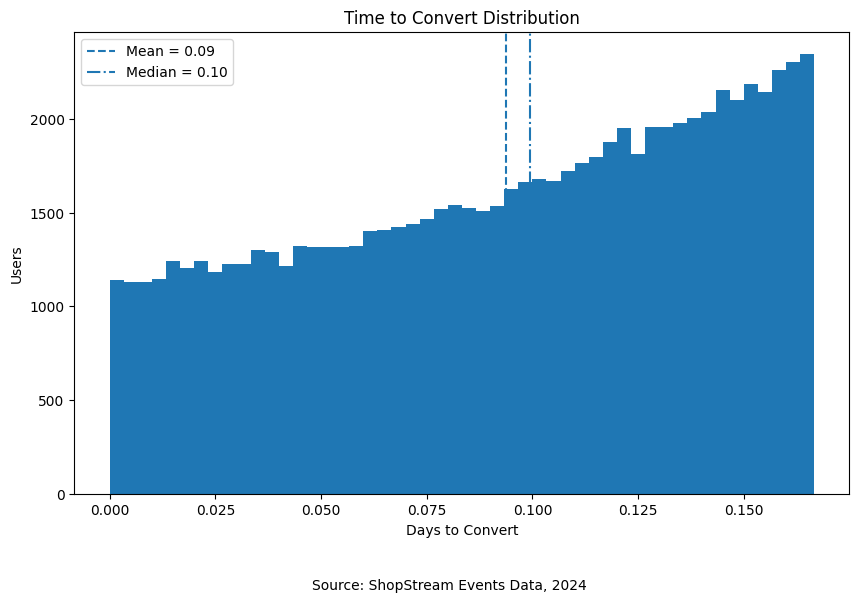

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    conversion_time['days_to_convert'],
    bins=50
)

plt.axvline(
    mean_days,
    linestyle='--',
    label=f'Mean = {mean_days:.2f}'
)

plt.axvline(
    median_days,
    linestyle='-.',
    label=f'Median = {median_days:.2f}'
)

plt.title('Time to Convert Distribution')
plt.xlabel('Days to Convert')
plt.ylabel('Users')
plt.legend()

plt.figtext(
    0.5,
    -0.05,
    'Source: ShopStream Events Data, 2024',
    ha='center'
)

plt.show()

In [37]:
print(conversion_time['days_to_convert'].describe())

count    80044.000000
mean         0.093846
std          0.047848
min          0.000000
25%          0.054306
50%          0.099340
75%          0.135833
max          0.166655
Name: days_to_convert, dtype: float64


In [38]:
conversion_time['days_to_convert'].sort_values().head(10)

24799    0.000000
51053    0.000000
14746    0.000000
2839     0.000012
28033    0.000012
52797    0.000012
10634    0.000012
68563    0.000012
58425    0.000012
39197    0.000023
Name: days_to_convert, dtype: float64

In [39]:
conversion_time['days_to_convert'].sort_values().tail(10)

29773    0.166644
29665    0.166655
28782    0.166655
36700    0.166655
33270    0.166655
66237    0.166655
5786     0.166655
3235     0.166655
43094    0.166655
75521    0.166655
Name: days_to_convert, dtype: float64

### Time-to-Convert Analysis

The average time between a customer's first recorded event and first purchase is approximately 2.25 hours.

50% of customers convert within 2.38 hours, while 75% convert within 3.26 hours.

The maximum observed conversion time is approximately 4 hours.

This suggests purchase activity occurs very quickly after the first tracked interaction, indicating a highly intent-driven shopping journey. The dataset appears to capture users near the point of purchase rather than the full customer discovery lifecycle.

In [40]:
products.columns

Index(['id', 'cost', 'category', 'name', 'brand', 'retail_price', 'department',
       'sku', 'distribution_center_id'],
      dtype='object')

In [41]:
events_valid.columns

Index(['id', 'user_id', 'sequence_number', 'session_id', 'created_at',
       'ip_address', 'city', 'state', 'postal_code', 'browser',
       'traffic_source', 'uri', 'event_type', 'device_type'],
      dtype='object')

In [42]:
events_valid['uri'].dropna().sample(20, random_state=42)

1096249                                                /cart
478713                                                 /cart
902018     /department/men/category/tops&tees/brand/polor...
124012                                             /purchase
950230                                                 /cart
1553340                                                /home
1914693                                                /cart
575533                                                 /cart
49393                                              /purchase
382379     /department/women/category/jeans/brand/l.a.ido...
2187335                                                /cart
299689                                                 /cart
1405283                                        /product/9957
1325454    /department/women/category/fashionhoodies&swea...
378256                                                 /cart
383939     /department/men/category/fashionhoodies&sweats...
2295713    /department/w

In [43]:
import re

events_valid['category'] = (
    events_valid['uri']
    .str.extract(r'category/([^/]+)')
)

events_valid[['uri','category']].head(10)

,uri,category
1251,/cart,NaN
1252,/cart,NaN
1253,/cart,NaN
1257,/cart,NaN
1259,/cart,NaN
1260,/cart,NaN
1262,/cart,NaN
1263,/cart,NaN
1264,/cart,NaN
1265,/cart,NaN


In [44]:
events_valid[
    events_valid['category'].notna()
][['uri','category']].head(20)

,uri,category
7316,/department/women/category/sleep&lounge/brand/...,sleep&lounge
7318,/department/women/category/active/brand/moving...,active
7321,/department/women/category/fashionhoodies&swea...,fashionhoodies&sweatshirts
7322,/department/women/category/swim/brand/lablanca,swim
7323,/department/women/category/swim/brand/speedo,swim
7324,/department/men/category/swim/brand/freegun,swim
7326,/department/men/category/tops&tees/brand/icebr...,tops&tees
7328,/department/women/category/jeans/brand/rich&sk...,jeans
7330,/department/men/category/tops&tees/brand/cubavera,tops&tees
7331,/department/women/category/active/brand/truere...,active


In [45]:
events_valid['category'].value_counts().head(25)

category
intimates                     25550
jeans                         24149
tops&tees                     22887
fashionhoodies&sweatshirts    22452
swim                          21783
sweaters                      21504
sleep&lounge                  21009
shorts                        20967
accessories                   18611
active                        17121
outerwear&coats               17109
underwear                     14319
pants                         13884
socks                         12026
dresses                       10473
suits&sportcoats               9985
maternity                      9751
plus                           8234
socks&hosiery                  7210
pants&capris                   6281
blazers&jackets                6069
leggings                       5987
skirts                         4108
suits                          1945
jumpsuits&rompers              1786
Name: count, dtype: int64

In [46]:
category_summary = (

    events_valid[
        events_valid['category'].notna()
    ]

    .groupby('category')

    .agg(
        Category_Views=('category','count'),
        Unique_Users=('user_id','nunique')
    )

    .reset_index()

    .sort_values(
        'Category_Views',
        ascending=False
    )

)

category_summary['Pct_Of_Category_Views'] = round(

    category_summary['Category_Views']
    /
    category_summary['Category_Views'].sum()
    *100,

    2
)

category_summary.head(25)

,category,Category_Views,Unique_Users,Pct_Of_Category_Views
6,intimates,25550,11371,7.39
7,jeans,24149,11669,6.99
24,tops&tees,22887,11010,6.62
5,fashionhoodies&sweatshirts,22452,10991,6.50
23,swim,21783,10591,6.30
22,sweaters,21504,10418,6.22
17,sleep&lounge,21009,10218,6.08
15,shorts,20967,10209,6.07
0,accessories,18611,9133,5.39
1,active,17121,8582,4.95


In [ ]:
## Category Engagement Analysis

Intimates is the most viewed category with 25,550 category interactions, followed by Jeans (24,149) and Tops & Tees (22,887).

The top five categories (Intimates, Jeans, Tops & Tees, Fashion Hoodies & Sweatshirts, and Swim) account for a significant share of customer browsing activity.

Customers demonstrate the highest engagement in apparel-focused categories, indicating strong demand for everyday fashion products.

Lower-engagement categories such as Suits, Jumpsuits & Rompers, and Skirts may require merchandising improvements or promotional campaigns to increase visibility.

Product discovery efforts should prioritize the top-performing categories while optimizing conversion opportunities within lower-engagement segments.

In [47]:
new_returning = pd.DataFrame({

    'User_Type':[
        'New User',
        'Returning User'
    ],

    'Users':[
        24394,
        3309
    ]
})

new_returning

,User_Type,Users
0,New User,24394
1,Returning User,3309


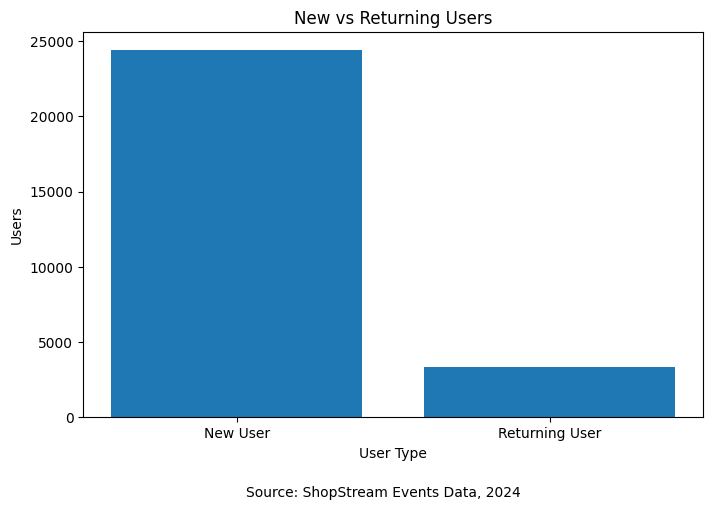

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    new_returning['User_Type'],
    new_returning['Users']
)

plt.title('New vs Returning Users')
plt.xlabel('User Type')
plt.ylabel('Users')

plt.figtext(
    0.5,
    -0.05,
    'Source: ShopStream Events Data, 2024',
    ha='center'
)

plt.show()

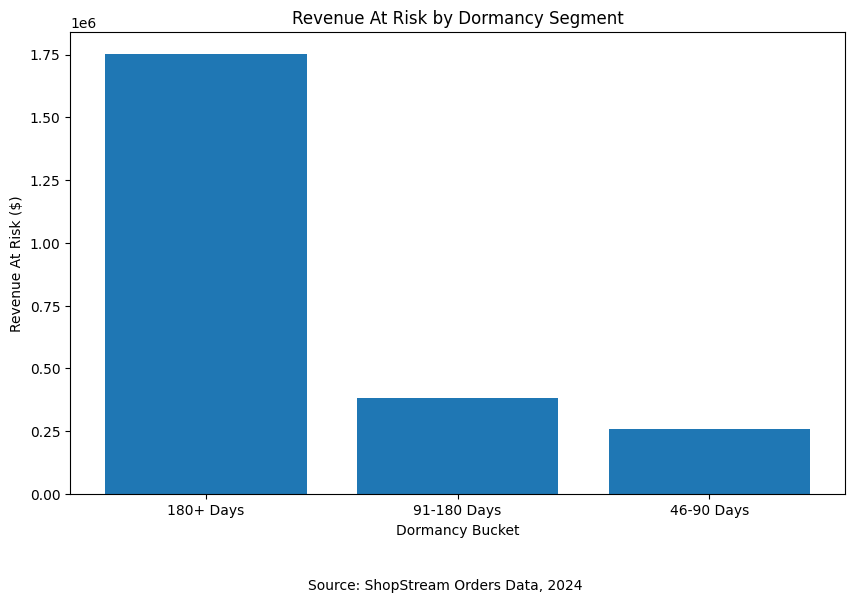

In [49]:
risk_df = pd.DataFrame({

    'Dormancy_Bucket':[
        '180+ Days',
        '91-180 Days',
        '46-90 Days'
    ],

    'Revenue_At_Risk':[

        1752213.03,
        381065.79,
        257810.05
    ]
})

plt.figure(figsize=(10,6))

plt.bar(
    risk_df['Dormancy_Bucket'],
    risk_df['Revenue_At_Risk']
)

plt.title('Revenue At Risk by Dormancy Segment')
plt.xlabel('Dormancy Bucket')
plt.ylabel('Revenue At Risk ($)')

plt.figtext(
    0.5,
    -0.05,
    'Source: ShopStream Orders Data, 2024',
    ha='center'
)

plt.show()

### Revenue At Risk Analysis

Customers inactive for more than 180 days represent the largest revenue recovery opportunity, accounting for approximately $1.75M in at-risk revenue.

The 180+ day segment contributes more than 70% of total dormant revenue exposure.

Targeted win-back campaigns, personalized offers, and re-engagement emails should prioritize this customer segment to maximize revenue recovery.

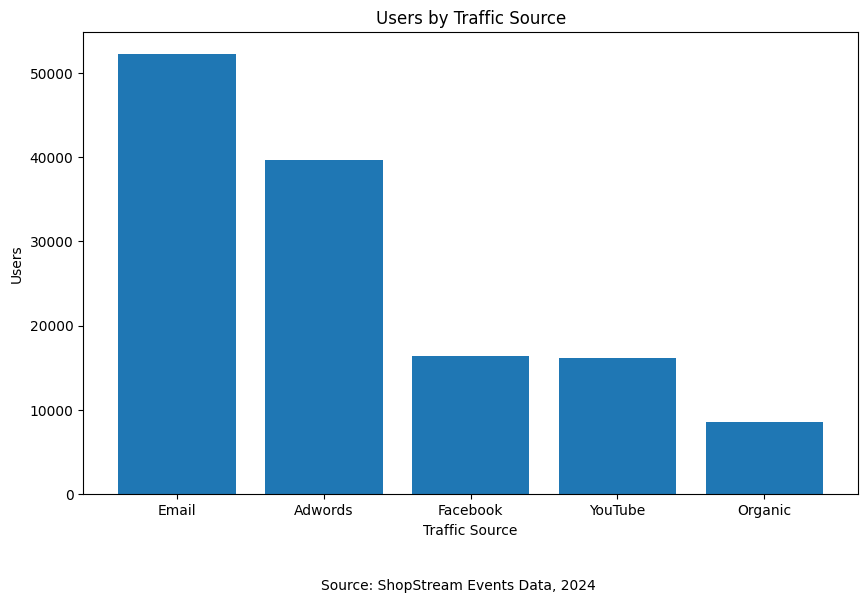

In [50]:
plt.figure(figsize=(10,6))

plt.bar(
    traffic_users['traffic_source'],
    traffic_users['users']
)

plt.title('Users by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Users')

plt.figtext(
    0.5,
    -0.05,
    'Source: ShopStream Events Data, 2024',
    ha='center'
)

plt.show()

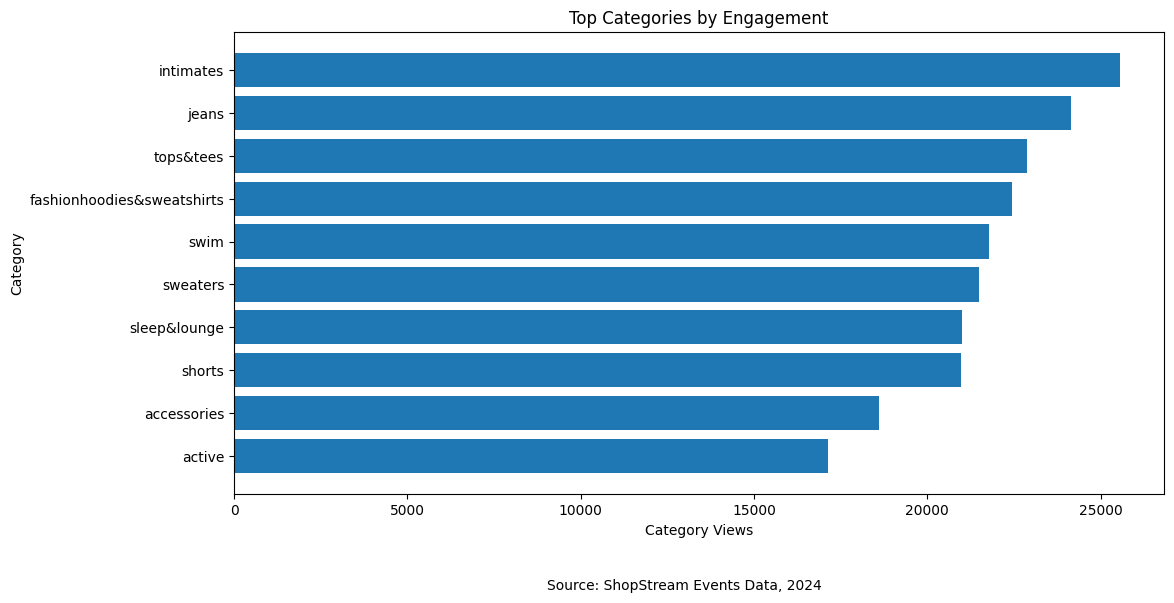

In [51]:
top_categories = category_summary.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_categories['category'],
    top_categories['Category_Views']
)

plt.title('Top Categories by Engagement')
plt.xlabel('Category Views')
plt.ylabel('Category')

plt.gca().invert_yaxis()

plt.figtext(
    0.5,
    -0.05,
    'Source: ShopStream Events Data, 2024',
    ha='center'
)

plt.show()

### Category Engagement Analysis

Intimates is the most engaged category with over 25K category interactions, followed by Jeans and Tops & Tees.

The top five categories account for a substantial share of customer browsing activity, indicating strong consumer interest in core apparel products.

Fashion basics and everyday wear dominate engagement patterns, suggesting merchandising and promotional efforts should prioritize these categories.

Lower-engagement categories such as Suits and Jumpsuits may require improved visibility, targeted promotions, or assortment optimization.

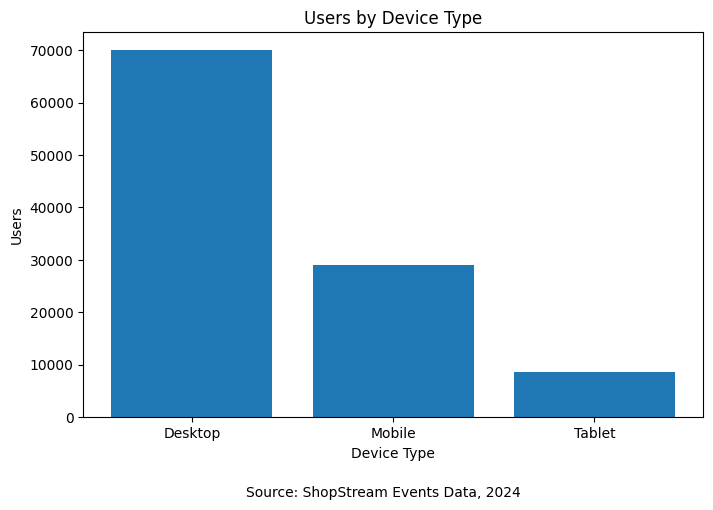

In [52]:
plt.figure(figsize=(8,5))

plt.bar(
    device_summary['Device_Type'],
    device_summary['Users']
)

plt.title('Users by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Users')

plt.figtext(
    0.5,
    -0.05,
    'Source: ShopStream Events Data, 2024',
    ha='center'
)

plt.show()

### Device Usage Analysis

Desktop is the dominant browsing platform, accounting for 65.14% of all users.

Mobile contributes 26.94% of users and remains an important secondary channel for customer acquisition and engagement.

Tablet traffic represents less than 8% of users and has limited business impact relative to desktop and mobile.

Given the strong desktop dominance, optimization efforts should prioritize desktop user experience while maintaining mobile usability for nearly one-third of the customer base.

# Executive Summary

## Objective

The objective of this analysis was to evaluate customer conversion behavior, traffic acquisition patterns, device usage, category engagement, customer retention, and revenue risk within the ShopStream e-commerce platform.

---

## Key Findings

### 1. Customer Acquisition

Email is the largest acquisition channel, contributing 39.3% of users, followed by Adwords at 29.8%.

Together, these two channels generate nearly 70% of platform traffic.

---

### 2. Device Usage

Desktop remains the dominant browsing platform, accounting for 65.1% of users.

Mobile contributes 26.9% of users, while tablet usage remains below 8%.

---

### 3. Customer Retention

New users account for 88.1% of customers, while returning users represent only 11.9%.

This indicates strong acquisition performance but relatively low retention performance.

---

### 4. Category Engagement

The most viewed categories are:

- Intimates
- Jeans
- Tops & Tees
- Fashion Hoodies & Sweatshirts
- Swim

Customer demand is concentrated within core apparel categories.

---

### 5. Conversion Timing

The average time between first recorded interaction and first purchase is approximately 2.25 hours.

75% of customers convert within approximately 3.3 hours.

This suggests highly intent-driven purchase behavior.

---

### 6. Revenue Risk

Customers inactive for more than 180 days represent approximately $1.75M in revenue at risk.

This segment should be prioritized for win-back campaigns and retention initiatives.

---

## Dataset Limitations

The event model does not support reconstruction of a true sequential conversion funnel because product, cart, and purchase users overlap almost completely.

As a result:

- Funnel drop-off analysis cannot be reliably measured.
- Device-level conversion testing is not statistically meaningful.
- Category-level cart abandonment cannot be accurately calculated from available event data.

These limitations were documented and alternative engagement-based analyses were performed where appropriate.

---

## Strategic Recommendations

1. Increase investment in high-performing acquisition channels (Email and Adwords).
2. Improve customer retention through loyalty and win-back campaigns.
3. Focus merchandising efforts on top-performing apparel categories.
4. Prioritize recovery of dormant customers with high revenue potential.
5. Continue monitoring device behavior and optimize the desktop experience while maintaining mobile performance.

---

Analysis Completed Successfully.